# McCann interpolation on a tree

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:monge-tree-mccann-interpolation`.  A finite weighted tree is a geodesic metric space: between two vertices there is a unique shortest path.  Given two histograms
$$
\alpha=\sum_i a_i\delta_{x_i},\qquad \beta=\sum_j b_j\delta_{x_j}
$$
on the vertices of the tree, we solve the discrete quadratic transport problem for the squared tree distance,
$$
\min_{P\in\mathbf U(a,b)} \sum_{i,j} d_{\mathsf T}(x_i,x_j)^2 P_{ij}.
$$
The induced displacement interpolation moves each packet $P_{ij}$ at constant speed along the unique tree geodesic from $x_i$ to $x_j$.  The exported panels render the evolving atomic measure on a planar drawing of the tree; circle areas are proportional to transported masses, colors interpolate from red to blue, and faint colored corridors indicate the tree branches used by the optimal plan.

In [ ]:
# --- OT4ML_COLAB_BOOTSTRAP: make this figure notebook runnable standalone in Colab.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys


def _ot4ml_find_repo_root():
    """Locate the OT4ML repository root for shared OT4ML assets.
    
    Returns:
        Repository root path located by the function.
    """
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install a package when the corresponding module is missing.
    
    Args:
        module_name: Python module name that should be importable.
        package_name: Package name to install when the module is unavailable.
    
    Returns:
        None. Imports the package if available, otherwise installs it first.
    """
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    ROOT = _OT4ML_Path("/content/ot4ml") if "google.colab" in _OT4ML_sys.modules else _OT4ML_Path.cwd() / "ot4ml"
    if ROOT.exists() and any(ROOT.iterdir()) and not (ROOT / ".git").exists():
        ROOT = ROOT.with_name(ROOT.name + "-repo")
    if not (ROOT / "notebooks-figures" / "figure_style.py").exists():
        _OT4ML_subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/gpeyre/ot4ml.git", str(ROOT)],
            check=True,
        )

_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)

if "google.colab" in _OT4ML_sys.modules:
    _ot4ml_ensure_package("ot", "POT")

VERBOSE = False

def log(*args, **kwargs):
    """Print diagnostics only when VERBOSE is enabled.
    
    Args:
        *args: Positional arguments forwarded to the wrapped callable.
        **kwargs: Keyword arguments forwarded to the wrapped callable.
    
    Returns:
        None. Prints diagnostic messages only when verbose mode is enabled.
    """
    if VERBOSE:
        print(*args, **kwargs)


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot

from figure_style import (
    BLUE,
    GRAY,
    RED,
    ROOT,
    box_axes,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
rng = np.random.default_rng(20260704)

NAME = "monge-tree-mccann-interpolation"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB_OUT = ROOT / "notebooks-figures" / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_OUT.mkdir(parents=True, exist_ok=True)

## A weighted planar tree

The drawing is only a visualization of the tree.  The actual cost is the path length in the tree, with each edge weighted by its Euclidean length in the drawing.  The source and target histograms are sparse but non-uniform, so the optimal plan splits mass across several branches.

In [2]:
coords = np.array([
    [0.00, 0.00],   # 0
    [-0.62, 0.42],  # 1
    [0.62, 0.44],   # 2
    [-0.42, -0.56], # 3
    [0.55, -0.52],  # 4
    [-1.14, 0.82],  # 5
    [-0.72, 1.12],  # 6
    [-0.30, 0.92],  # 7
    [0.34, 1.02],   # 8
    [1.08, 0.86],   # 9
    [1.02, 0.28],   # 10
    [-0.98, -0.94], # 11
    [-0.22, -1.06], # 12
    [0.25, -1.00],  # 13
    [1.00, -0.88],  # 14
    [0.86, -0.26],  # 15
    [-1.52, 1.10],  # 16
    [1.48, 1.08],   # 17
    [-1.36, -1.22], # 18
    [1.45, -1.10],  # 19
    [0.02, 1.42],   # 20
    [-0.05, -1.46], # 21
], dtype=float)

edges = [
    (0, 1), (0, 2), (0, 3), (0, 4),
    (1, 5), (1, 6), (1, 7),
    (2, 8), (2, 9), (2, 10),
    (3, 11), (3, 12),
    (4, 13), (4, 14), (4, 15),
    (5, 16), (9, 17), (11, 18), (14, 19), (8, 20), (12, 21),
]

n = len(coords)
edge_length = {}
adj = [[] for _ in range(n)]
for u, v in edges:
    length = float(np.linalg.norm(coords[u] - coords[v]))
    edge_length[(u, v)] = edge_length[(v, u)] = length
    adj[u].append(v)
    adj[v].append(u)

# Root the tree once.  This makes path extraction by lowest common ancestor easy.
root = 0
parent = np.full(n, -1, dtype=int)
depth = np.zeros(n, dtype=int)
order = [root]
parent[root] = root
for u in order:
    for v in adj[u]:
        if parent[v] == -1:
            parent[v] = u
            depth[v] = depth[u] + 1
            order.append(v)

assert len(order) == n, "The graph should be connected."
assert len(edges) == n - 1, "The graph should be a tree."


def path_vertices(i, j):
    """Unique vertex path from i to j in the rooted tree.
    
    Args:
        i: Source index, row index, or first endpoint index.
        j: Target index, column index, or second endpoint index.
    
    Returns:
        Ordered list of vertices along the unique tree path.
    """
    left, right = [], []
    u, v = int(i), int(j)
    while depth[u] > depth[v]:
        left.append(u)
        u = parent[u]
    while depth[v] > depth[u]:
        right.append(v)
        v = parent[v]
    while u != v:
        left.append(u)
        right.append(v)
        u = parent[u]
        v = parent[v]
    left.append(u)
    return left + right[::-1]


def tree_distance(i, j):
    """Compute tree distance.
    
    Args:
        i: Source index, row index, or first endpoint index.
        j: Target index, column index, or second endpoint index.
    
    Returns:
        Tree distance values.
    """
    path = path_vertices(i, j)
    return sum(edge_length[(u, v)] for u, v in zip(path[:-1], path[1:]))

D = np.array([[tree_distance(i, j) for j in range(n)] for i in range(n)])
C = D**2

alpha = np.zeros(n)
beta = np.zeros(n)
for i, mass in {16: 0.17, 6: 0.11, 18: 0.22, 11: 0.12, 13: 0.18, 1: 0.08, 3: 0.12}.items():
    alpha[i] = mass
for i, mass in {17: 0.22, 20: 0.18, 19: 0.21, 10: 0.13, 7: 0.11, 15: 0.15}.items():
    beta[i] = mass
alpha /= alpha.sum()
beta /= beta.sum()

P = ot.emd(alpha, beta, C, numItermax=200000)
support = [(i, j, float(P[i, j])) for i in range(n) for j in range(n) if P[i, j] > 1e-12]
log(f"Active transport packets: {len(support)}")
log(f"Quadratic tree transport cost: {float((P*C).sum()):.4f}")


Active transport packets: 11
Quadratic tree transport cost: 7.1998


## Interpolating along tree geodesics

For a pair of vertices $(i,j)$ and a time $t$, the atom travels a fraction $t$ of the path length from $i$ to $j$.  At intermediate times atoms may sit inside edges, not only on vertices.  This is the tree analogue of the Euclidean McCann interpolation induced by a Kantorovich plan.  To make the dynamics readable at book size, the figure also overlays the active tree corridors, with widths proportional to the mass transported through each edge.

In [3]:
def point_on_path(i, j, t):
    """Simulate point on path for the time snapshots shown in the figure.
    
    Args:
        i: Source index, row index, or first endpoint index.
        j: Target index, column index, or second endpoint index.
        t: Interpolation time or evolution time parameter.
    
    Returns:
        Interpolated point located at time `t` along the tree path.
    """
    path = path_vertices(i, j)
    total = D[i, j]
    if total <= 1e-14:
        return coords[i].copy()
    remaining = float(t * total)
    for u, v in zip(path[:-1], path[1:]):
        length = edge_length[(u, v)]
        if remaining <= length + 1e-14:
            s = np.clip(remaining / length, 0.0, 1.0)
            return (1 - s) * coords[u] + s * coords[v]
        remaining -= length
    return coords[j].copy()


def aggregate_atoms(points, masses, decimals=5):
    """Compute aggregate atoms.
    
    Args:
        points: Point cloud used by the geometric construction.
        masses: Mass values attached to the displayed atoms.
        decimals: Number of decimal places used in labels.
    
    Returns:
        Aggregate atoms values.
    """
    acc = {}
    for p, m in zip(points, masses):
        key = tuple(np.round(p, decimals=decimals))
        if key not in acc:
            acc[key] = [p.copy(), 0.0]
        acc[key][1] += float(m)
    pts = np.array([v[0] for v in acc.values()])
    ms = np.array([v[1] for v in acc.values()])
    return pts, ms


def interpolated_atoms(t):
    """Interpolate discretized measures or fields at requested times.
    
    Args:
        t: Interpolation time or evolution time parameter.
    
    Returns:
        Interpolated samples or density values at the requested time.
    """
    pts = [point_on_path(i, j, t) for i, j, _ in support]
    ms = [mass for _, _, mass in support]
    return aggregate_atoms(np.asarray(pts), np.asarray(ms))


def canonical_edge(u, v):
    """Compute canonical edge.
    
    Args:
        u: Dual variable, velocity coordinate, or auxiliary array.
        v: Velocity field, dual variable, or auxiliary array.
    
    Returns:
        Canonical edge values.
    """
    return (u, v) if u < v else (v, u)


edge_flux = {canonical_edge(u, v): 0.0 for u, v in edges}
for i, j, mass in support:
    path = path_vertices(i, j)
    for u, v in zip(path[:-1], path[1:]):
        edge_flux[canonical_edge(u, v)] += mass
max_flux = max(edge_flux.values())


def draw_tree(ax, *, lw=0.72):
    """Render the tree with the OT4ML plotting style.
    
    Args:
        ax: Matplotlib axes on which the object is drawn.
        lw: Line width used for drawing curves or segments.
    
    Returns:
        None. Draws on the provided Matplotlib axes.
    """
    for u, v in edges:
        xy = coords[[u, v]]
        ax.plot(xy[:, 0], xy[:, 1], color="#222222", lw=lw, alpha=0.62, zorder=1, solid_capstyle="round")
    ax.scatter(coords[:, 0], coords[:, 1], s=4.4, color="#222222", alpha=0.48, zorder=2, linewidth=0)


def draw_transport_corridors(ax, t):
    # Active tree branches used by the optimal plan, kept faint so the mass circles remain dominant.
    """Render the transport corridors with the OT4ML plotting style.
    
    Args:
        ax: Matplotlib axes on which the object is drawn.
        t: Interpolation time or evolution time parameter.
    
    Returns:
        None. Draws on the provided Matplotlib axes.
    """
    color = interp_color(t)
    for u, v in edges:
        flux = edge_flux[canonical_edge(u, v)]
        if flux <= 1e-12:
            continue
        xy = coords[[u, v]]
        lw = 0.18 + 4.6 * flux / max_flux
        ax.plot(xy[:, 0], xy[:, 1], color=color, lw=lw, alpha=0.18, zorder=3, solid_capstyle="round")


def draw_panel(ax, t, *, label=False):
    """Render one figure panel with the OT4ML plotting style.
    
    Args:
        ax: Matplotlib axes on which the object is drawn.
        t: Interpolation time or evolution time parameter.
        label: Text label used in the figure.
    
    Returns:
        None. Draws on the provided Matplotlib axes.
    """
    draw_tree(ax)
    draw_transport_corridors(ax, t)
    pts, masses = interpolated_atoms(t)
    sizes = 5.0 + 1350.0 * masses
    ax.scatter(
        pts[:, 0], pts[:, 1],
        s=sizes,
        marker="o",
        color=interp_color(t),
        edgecolor="white",
        linewidth=0.42,
        alpha=0.98,
        zorder=4,
    )
    ax.set_aspect("equal")
    ax.set_xlim(-2.05, 2.05)
    ax.set_ylim(-1.78, 1.72)
    remove_axes(ax)
    if label:
        ax.set_title(fr"$t={t:.2g}$", fontsize=8.5, pad=0.8)

for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
    pts, masses = interpolated_atoms(t)
    log(f"t={t:4.2f}: {len(pts):2d} visible atoms, total mass={masses.sum():.6f}")
log(f"Active tree branches: {sum(v > 1e-12 for v in edge_flux.values())} / {len(edges)}")


t=0.00:  7 visible atoms, total mass=1.000000
t=0.25: 11 visible atoms, total mass=1.000000
t=0.50: 11 visible atoms, total mass=1.000000
t=0.75: 11 visible atoms, total mass=1.000000
t=1.00:  6 visible atoms, total mass=1.000000
Active tree branches: 19 / 21


## Exported panels

The individual PDF panels have no embedded titles.  The manuscript supplies the time labels and the caption.  The thumbnail below is only for the notebook and web gallery.

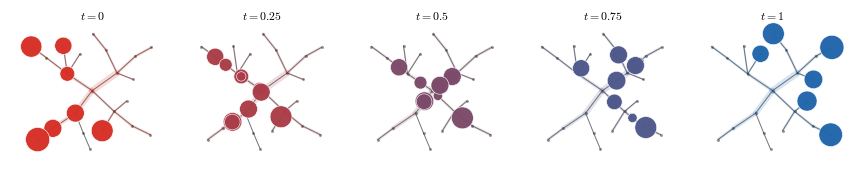

In [4]:
times = [(0.0, "time-000.pdf"), (0.25, "time-025.pdf"), (0.5, "time-050.pdf"), (0.75, "time-075.pdf"), (1.0, "time-100.pdf")]

for t, filename in times:
    fig, ax = plt.subplots(figsize=(1.72, 1.60))
    draw_panel(ax, t)
    save_pdf(fig, OUT / filename, pad_inches=0.006)
    fig.savefig(ARXIV_OUT / f"{NAME}--{filename}", bbox_inches="tight", pad_inches=0.006)
    plt.close(fig)

fig, axes = plt.subplots(1, 5, figsize=(8.55, 1.72))
for ax, (t, _) in zip(axes, times):
    draw_panel(ax, t, label=True)
fig.subplots_adjust(wspace=0.035, left=0.006, right=0.994, bottom=0.005, top=0.88)
fig.savefig(THUMB_OUT / f"{NAME}.png", dpi=230, bbox_inches="tight", pad_inches=0.01)
plt.show()

## Figure preview

The output below embeds the generated thumbnail so the figure renders directly on GitHub.

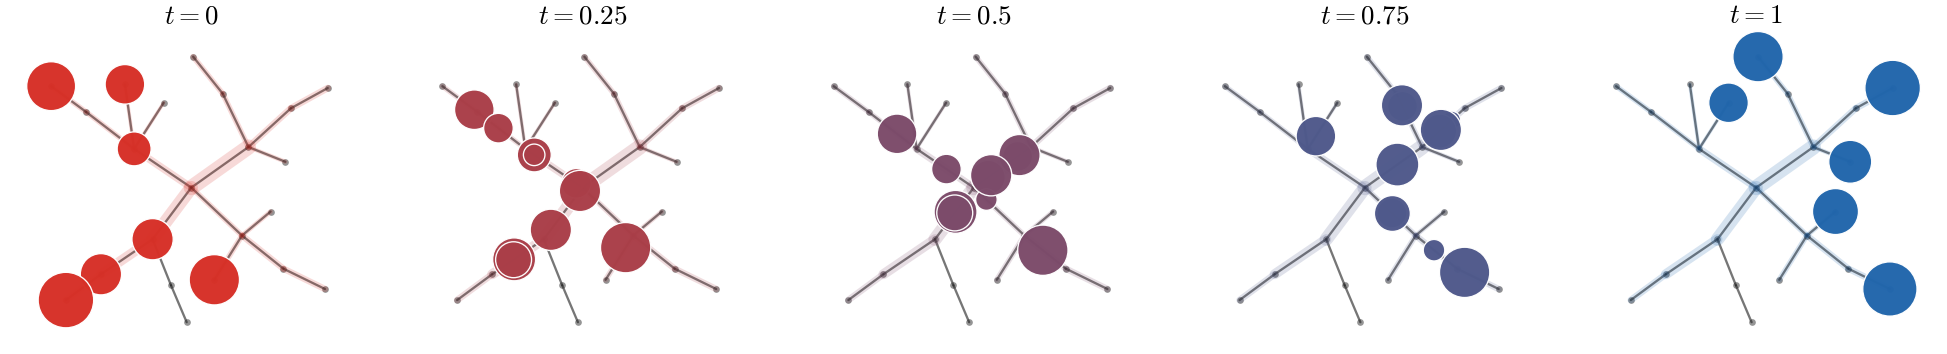

In [5]:
from IPython.display import Image, display
thumb = THUMB_OUT / f"{NAME}.png"
display(Image(filename=str(thumb), width=920))